In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.patches import Patch
import matplotlib.colors as mcolors
from scipy import stats
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
import statsmodels.api as sm
import io

In [7]:
whiteouts = pd.read_csv('white_out_plays.csv')
penn_plays = pd.read_csv('penn_state_plays.csv')
penn_games = pd.read_csv('penn_state_plays.csv')
oregon_games = pd.read_csv('oregon_games_data.csv')
plays = pd.read_csv('p4_p4_plays.csv')

# penn_games.columns

C:\Users\bchm5\AppData\Local\Temp\ipykernel_23780\3286598725.py:5: DtypeWarning: Columns (1) have mixed types. Specify dtype option on import or set low_memory=False.
  plays = pd.read_csv('p4_p4_plays.csv')


In [19]:
plays['def_penalty'].value_counts()

def_penalty
0    47777
1     1630
Name: count, dtype: int64

In [8]:
def get_orun_tendencies(df, label):
    df = df.copy()
    
    numeric_cols = ['success', 'touchdown', 'turnover', 'off_penalty', 'def_penalty',
                    'interception', 'fumble', 'motion', 'shift', 'play_action', 'pressure',
                    'sack', 'blitz_dog', 'mug_look', 'box_players_count', 'no_huddle',
                    'tempo', 'unbalanced', 'screen', 'draw', 'trick_play', 'trick_look',
                    'expected_points_added', 'gain_loss', 'first_down_gained', 'option',
                    'run_pass_option', 'stunt', 'safety_count', 'box_players_on_los_count',
                    'defensive_line_shift', 'pass_breakup', 'missed_tackle', 'blitz_dog']
    
    for col in numeric_cols:
        if col in df.columns:
            df[col] = pd.to_numeric(df[col], errors='coerce')

    # offensive tendencies — gameplan decisions
    orun_offense = df[df['offense'] == 'ORUN'].copy()
    orun_offense['first_down_gained_numeric'] = orun_offense['first_down_gained'].fillna(0)

    orun_offense_by_game = orun_offense.groupby(['season', 'week', 'pff_game_id']).agg(
        off_plays=('pff_play_id', 'size'),
        # run/pass gameplan
        pass_rate=('run_pass', lambda x: (x == 'P').mean()),
        run_rate=('run_pass', lambda x: (x == 'R').mean()),
        # pre-snap decisions
        motion_rate=('motion', 'mean'),
        shift_rate=('shift', 'mean'),
        no_huddle_rate=('no_huddle', 'mean'),
        tempo_rate=('tempo', 'mean'),
        unbalanced_rate=('unbalanced', 'mean'),
        # play design
        play_action_rate=('play_action', 'mean'),
        screen_rate=('screen', 'mean'),
        draw_rate=('draw', 'mean'),
        option_rate=('option', 'mean'),
        rpo_rate=('run_pass_option', 'mean'),
        trick_play_rate=('trick_play', 'mean'),
        trick_look_rate=('trick_look', 'mean'),
        # protection
        pressure_allowed_rate=('pressure', 'mean'),
        sack_allowed_rate=('sack', 'mean'),
        # penalties
        off_penalty_rate=('off_penalty', 'mean'),
    ).reset_index()

    # defensive tendencies — gameplan decisions
    orun_defense = df[df['defense'] == 'ORUN'].copy()

    orun_defense_by_game = orun_defense.groupby(['season', 'week', 'pff_game_id']).agg(
        def_plays=('pff_play_id', 'size'),
        # pass rush gameplan
        blitz_rate=('blitz_dog', 'mean'),
        stunt_rate=('stunt', 'mean'),
        pressure_generated_rate=('pressure', 'mean'),
        sack_generated_rate=('sack', 'mean'),
        # coverage/alignment
        box_count_avg=('box_players_count', 'mean'),
        box_los_count_avg=('box_players_on_los_count', 'mean'),
        safety_count_avg=('safety_count', 'mean'),
        mug_rate=('mug_look', 'mean'),
        def_line_shift_rate=('defensive_line_shift', 'mean'),
        # results
        pass_breakup_rate=('pass_breakup', 'mean'),
        missed_tackle_rate=('missed_tackle', 'mean'),
        def_penalty_rate=('def_penalty', 'mean'),
        opp_pass_rate=('run_pass', lambda x: (x == 'P').mean()),
        opp_run_rate=('run_pass', lambda x: (x == 'R').mean()),
        opp_motion_rate=('motion', 'mean'),
        opp_no_huddle_rate=('no_huddle', 'mean'),
    ).reset_index()

    orun_by_game = pd.merge(orun_offense_by_game, orun_defense_by_game,
                             on=['season', 'week', 'pff_game_id'],
                             suffixes=('_off', '_def'))

    totals = orun_by_game.mean(numeric_only=True)
    totals['season'] = 'TOTAL'
    totals['week'] = '-'
    totals['pff_game_id'] = '-'
    orun_by_game = pd.concat([orun_by_game, totals.to_frame().T], ignore_index=True)

    # not_included = ['play_action_rate', 'screen_rate', 'draw_rate', 'option_rate', 'rpo_rate', 'trick_play_rate', 'trick_look_rate', 'sack_allowed_rate', 
    #                 ]
    # included = ['season', 'pff_game_id', 'run_rate', 'pass_rate', 'motion_rate', 'shift_rate', 'tempo_rate', 'unbalanced_rate', 'pressure_allowed_rate', 'off_penalty_rate',
    #                 'blitz_rate', ]
    # orun_by_game = orun_by_game[included]

    print(f"\n{'='*60}")
    print(f"ORUN Tendencies — {label} ({len(orun_by_game) - 1} games)")
    print(f"{'='*60}")
    print(orun_by_game.to_string())
    return orun_by_game



In [22]:
oregon_tendencies = get_orun_tendencies(oregon_games, 'All Oregon Games')
# whiteout_tendencies = get_orun_tendencies(whiteouts, 'Whiteout Games')


ORUN Tendencies — All Oregon Games (12 games)
   season week pff_game_id  off_plays pass_rate  run_rate motion_rate shift_rate no_huddle_rate tempo_rate unbalanced_rate play_action_rate screen_rate draw_rate option_rate  rpo_rate trick_play_rate trick_look_rate pressure_allowed_rate sack_allowed_rate off_penalty_rate def_plays blitz_rate stunt_rate pressure_generated_rate sack_generated_rate box_count_avg box_los_count_avg safety_count_avg mug_rate def_line_shift_rate pass_breakup_rate missed_tackle_rate def_penalty_rate opp_pass_rate opp_run_rate opp_motion_rate opp_no_huddle_rate
0    2025   02       28886         68  0.426471  0.514706    0.470588   0.147059            0.0   0.205882        0.132353         0.161765    0.102941  0.014706    0.073529  0.205882        0.044118        0.029412              0.102941               0.0         0.073529        67   0.268657   0.104478                0.164179            0.029851      6.253731          4.208955         1.686567      NaN    

C:\Users\bchm5\AppData\Local\Temp\ipykernel_23780\2012848256.py:77: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value 'TOTAL' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  totals['season'] = 'TOTAL'


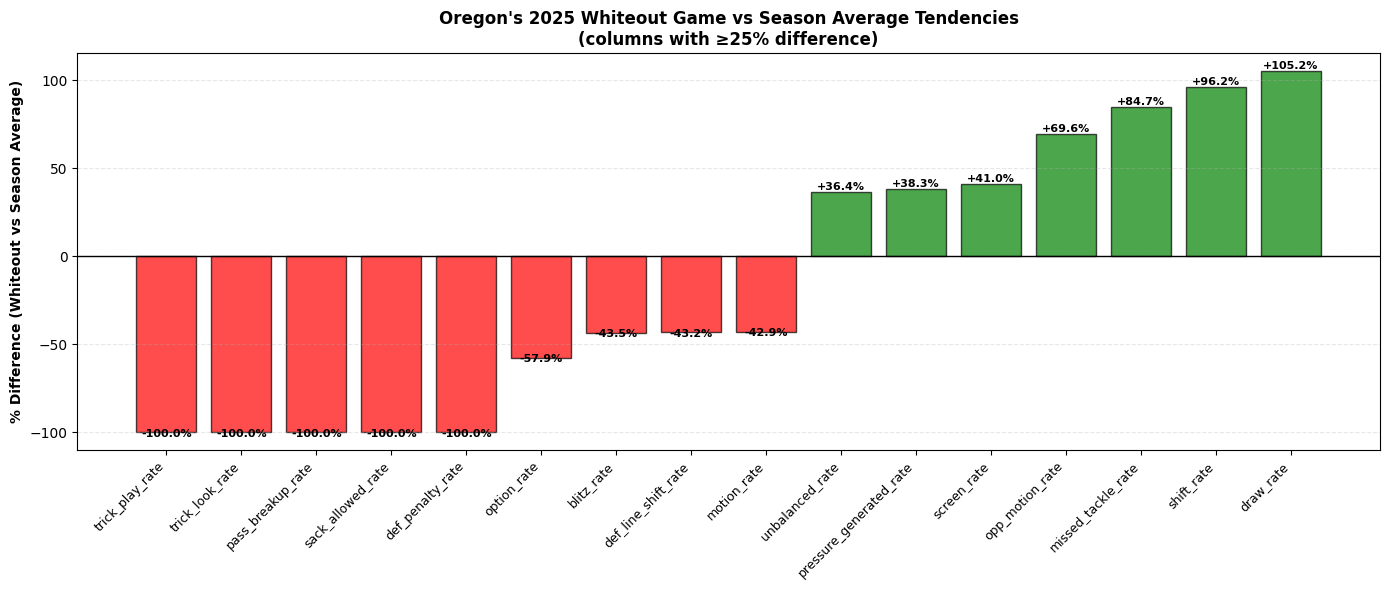

In [18]:
# define the two rows manually
whiteout_2025 = oregon_tendencies[oregon_tendencies['pff_game_id'] == 29087].iloc[0]
avg_2025 = oregon_tendencies[oregon_tendencies['season'] == 'TOTAL'].iloc[0]

skip_cols = ['off_plays', 'def_plays', 'season', 'week', 'pff_game_id']
diff_data = {}

numeric_cols = [col for col in oregon_tendencies.columns if col not in skip_cols]

for col in numeric_cols:
    avg_val = pd.to_numeric(avg_2025[col], errors='coerce')
    wo_val = pd.to_numeric(whiteout_2025[col], errors='coerce')
    
    if pd.isna(avg_val) or pd.isna(wo_val) or avg_val == 0:
        continue
    
    pct_diff = abs(avg_val - wo_val) / abs(avg_val)
    if pct_diff >= 0.25:
        diff_data[col] = (wo_val - avg_val) / abs(avg_val) * 100

diff_series = pd.Series(diff_data).sort_values()

colors = ['green' if v > 0 else 'red' for v in diff_series]

fig, ax = plt.subplots(figsize=(14, 6))
bars = ax.bar(range(len(diff_series)), diff_series.values, color=colors, alpha=0.7, edgecolor='black')

for bar, val in zip(bars, diff_series.values):
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + (1 if val >= 0 else -2.5),
            f'{val:+.1f}%', ha='center', fontsize=8, fontweight='bold')

ax.set_xticks(range(len(diff_series)))
ax.set_xticklabels(diff_series.index, rotation=45, ha='right', fontsize=9)
ax.axhline(0, color='black', linewidth=1)
ax.set_ylabel('% Difference (Whiteout vs Season Average)', fontweight='bold')
ax.set_title("Oregon's 2025 Whiteout Game vs Season Average Tendencies\n(columns with ≥25% difference)", fontweight='bold')
ax.grid(axis='y', alpha=0.3, linestyle='--')
plt.tight_layout()
plt.show()

In [8]:
whiteouts[whiteouts['offense'] == 'ORUN'][['shift']].value_counts()

shift
0        66
1        27
Name: count, dtype: int64

In [ ]:
print(oregon_tendencies[oregon_tendencies['season'] == 'TOTAL'])


   season week pff_game_id  off_plays pass_rate  run_rate motion_rate  \
12  TOTAL    -           -  69.666667  0.491751  0.488149     0.43263   

   shift_rate no_huddle_rate tempo_rate  ... safety_count_avg mug_rate  \
12   0.169892            0.0   0.151168  ...         1.800955      NaN   

   def_line_shift_rate pass_breakup_rate missed_tackle_rate def_penalty_rate  \
12            0.056766          0.034473           0.122259          0.02348   

   opp_pass_rate opp_run_rate opp_motion_rate opp_no_huddle_rate  
12      0.486446     0.483097         0.39935                0.0  

[1 rows x 38 columns]


In [52]:
oregon_games[(oregon_games['pff_game_id'] == 29087) & (oregon_games['offense'] == 'ORUN')]['play_type'].value_counts()
# oregon_tendencies

play_type
dropback        40
designed run    38
no play          3
Name: count, dtype: int64